# Deskriptive Analyse (inkl. min/max group sizes)

Wir laden die Ergebnisse und schauen zusätzlich, wie Distanz-Mittelwerte variieren mit `min_observations` und `max_observations`.


In [2]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

results_csv = Path(r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\all_results_combined.csv")
df = pd.read_csv(results_csv)

df.head
df

,trail_a_id,trail_b_id,samples_a,samples_b,ind_a,ind_b,same_individual,fold,pipeline,selection_method,...,dist_chebyshev,dist_canberra,dist_braycurtis,dist_mahalanobis,avg_proba_A_0,avg_proba_A_1,avg_proba_B_0,avg_proba_B_1,avg_proba_R_0,avg_proba_R_1
0,leni_4p,nokia_4n,"[191, 194, 183, 181]","[140, 144, 142, 138]",leni,nokia,False,2,random_forest_k2_lda_nc2,random_forest,...,1.784977,1.374365,1.785765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,leni_4p,nokia_4n,"[191, 194, 183, 181]","[140, 144, 142, 138]",leni,nokia,False,2,random_forest_k5_lda_nc2,random_forest,...,2.612136,1.203876,1.242241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,leni_4p,nokia_4n,"[191, 194, 183, 181]","[140, 144, 142, 138]",leni,nokia,False,2,random_forest_k8_lda_nc2,random_forest,...,3.643024,1.031010,1.483454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,leni_4p,nokia_4n,"[191, 194, 183, 181]","[140, 144, 142, 138]",leni,nokia,False,2,random_forest_k10_lda_nc2,random_forest,...,3.670573,1.053258,1.378547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,leni_4p,nokia_4n,"[191, 194, 183, 181]","[140, 144, 142, 138]",leni,nokia,False,2,random_forest_k12_lda_nc2,random_forest,...,3.668281,1.261780,1.167410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,japet_8t,japet_10a,"[86, 84, 89, 94, 87, 91, 99, 83]","[96, 85, 90, 100, 98, 82, 88, 92, 93, 97]",japet,japet,True,0,random_forest_k30_lda_nc2,random_forest,...,2.604354,1.086157,0.519495,NaN,0.0,1.0,0.0,1.0,0.562319,0.437681
2796,japet_8t,japet_10a,"[86, 84, 89, 94, 87, 91, 99, 83]","[96, 85, 90, 100, 98, 82, 88, 92, 93, 97]",japet,japet,True,0,random_forest_k50_lda_nc2,random_forest,...,3.976468,1.015824,0.570117,NaN,0.0,1.0,0.0,1.0,0.562319,0.437681
2797,japet_8t,japet_10a,"[86, 84, 89, 94, 87, 91, 99, 83]","[96, 85, 90, 100, 98, 82, 88, 92, 93, 97]",japet,japet,True,0,random_forest_k100_lda_nc2,random_forest,...,6.271871,1.025446,0.637854,NaN,0.0,1.0,0.0,1.0,0.562319,0.437681
2798,japet_8t,japet_10a,"[86, 84, 89, 94, 87, 91, 99, 83]","[96, 85, 90, 100, 98, 82, 88, 92, 93, 97]",japet,japet,True,0,random_forest_k150_lda_nc2,random_forest,...,8.165804,1.125465,0.794479,NaN,0.0,1.0,0.0,1.0,0.562319,0.437681


## 1 Mittlere Distanzen nach Gruppengrößen


In [5]:
# Cell 2: Gruppieren
group = df.groupby([
    "selection_method","reducer",
    "k_features","n_components",
    "min_observations","max_observations",
    "same_individual"
])[
    ["dist_braycurtis","dist_cosine"]
].mean().reset_index()

group.head(10)


,selection_method,reducer,k_features,n_components,min_observations,max_observations,same_individual,dist_braycurtis,dist_cosine
0,random_forest,lda,2,2,2,2,False,1.065764,1.351348
1,random_forest,lda,2,2,2,2,True,0.676596,0.485883
2,random_forest,lda,2,2,2,3,False,1.691455,1.385873
3,random_forest,lda,2,2,2,3,True,1.202865,1.073963
4,random_forest,lda,2,2,2,4,False,1.194736,1.145784
5,random_forest,lda,2,2,2,4,True,0.790314,0.526495
6,random_forest,lda,2,2,2,5,False,1.144860,0.948457
7,random_forest,lda,2,2,2,5,True,1.128759,0.600719
8,random_forest,lda,2,2,2,6,False,1.999466,1.366908
9,random_forest,lda,2,2,2,6,True,0.737659,0.451182


In [3]:
# Cell 3: Cross-Validation by Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

# The three distance features you care about:
features = ["dist_euclidean", "dist_braycurtis", "dist_cosine"]

# Pull all unique pipelines from your results DataFrame
pipelines = df["pipeline"].unique()

# Use GroupKFold on comparison_id to prevent leakage across pair comparisons
gkf = GroupKFold(n_splits=5)
records = []

for pipe in pipelines:
    sub = df[df["pipeline"] == pipe]
    # skip small sets
    if len(sub) < 30:
        continue

    X = sub[features].values
    y = sub["same_individual"].astype(int).values
    groups = sub["comparison_id"].values





    clf = RandomForestClassifier(n_estimators=100, random_state=0)
    bal_scores = cross_val_score(
        clf, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring="balanced_accuracy",
        n_jobs=-1
    )
    auc_scores = cross_val_score(
        clf, X, y,
        cv=gkf.split(X, y, groups=groups),
        scoring="roc_auc",
        n_jobs=-1
    )

    records.append({
        "pipeline":        pipe,
        "bal_mean":        bal_scores.mean(),
        "bal_std":         bal_scores.std(),
        "auc_mean":        auc_scores.mean(),
        "auc_std":         auc_scores.std(),
        "n_pairs":         len(sub)
    })

res_df = pd.DataFrame(records)
res_df.sort_values("auc_mean", ascending=False).reset_index(drop=True)


,pipeline,bal_mean,bal_std,auc_mean,auc_std,n_pairs
0,random_forest_k18_lda_nc2,0.829167,0.102402,0.913901,0.051651,200
1,random_forest_k12_lda_nc2,0.792927,0.087036,0.903593,0.054289,200
2,random_forest_k20_lda_nc2,0.768750,0.057584,0.901768,0.046221,200
3,random_forest_k8_lda_nc2,0.799177,0.029504,0.900582,0.063050,200
4,random_forest_k30_lda_nc2,0.782738,0.075668,0.891608,0.072965,200
5,random_forest_k2_lda_nc2,0.777153,0.103711,0.890301,0.036765,200
6,random_forest_k5_lda_nc2,0.725070,0.124163,0.886870,0.052003,200
7,random_forest_k16_lda_nc2,0.827083,0.076149,0.882878,0.071072,200
8,random_forest_k200_lda_nc2,0.763936,0.099815,0.880738,0.039354,200
9,random_forest_k10_lda_nc2,0.752714,0.090734,0.879552,0.071951,200


In [4]:
# %% 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# –– 1) Assume you already have `res_df` loaded into memory
# If you need to read it from disk, uncomment the next line:
# res_df = pd.read_csv("path/to/your/all_results_combined.csv")

# –– 2) Make sure the flag column is boolean
res_df['use_sexmodel_prediction'] = res_df['use_sexmodel_prediction'].astype(bool)

# –– 3) Prepare the two groups
grouped = res_df.groupby('use_sexmodel_prediction')['bal_mean']
data_false = grouped.get_group(False)
data_true  = grouped.get_group(True)

# –– 4) Box-plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([data_false, data_true], labels=['sex_off', 'sex_on'])
ax.set_ylabel('Balanced accuracy (mean)')
ax.set_title('Effect of sex‐model features on Balanced Accuracy')
plt.tight_layout()
plt.show()

# %% 
# –– 5) Mann–Whitney U test
stat, pval = mannwhitneyu(data_false, data_true, alternative='two-sided')
print(f"Mann–Whitney U  stat={stat:.3f}, p-value={pval:.3e}")

if pval < 0.05:
    print("→ Significant difference in balanced accuracy (p<0.05)")
else:
    print("→ No significant difference detected (p≥0.05)")


KeyError: 'use_sexmodel_prediction'

In [18]:
# %% Speichere Cluster-Labels und Dendrogramme für alle Distanzmaße
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import fcluster

# 1) CSV laden (Dein bereits eingelesenes df)
df = pd.read_csv(
    r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\cluster_csv.csv",
    decimal=","
)

measures = [
    "dist_euclidean",
    "dist_manhattan",
    "dist_cosine",
    "dist_chebyshev",
    "dist_canberra",
    "dist_braycurtis",
    "dist_mahalanobis"
]

output_dir = Path("C:/Users/Frede/OneDrive/Projects and Disschaptors/FIT_package/results/data/clusters")
output_dir.mkdir(exist_ok=True)

for measure in measures:
    trails = sorted(set(df["trail_a_id"]) | set(df["trail_b_id"]))
    # Build complete distance matrix, fill NaNs with max
    D = pd.DataFrame(np.nan, index=trails, columns=trails)
    for a, b, val in zip(df["trail_a_id"], df["trail_b_id"], df[measure]):
        try:
            D.at[a, b] = D.at[b, a] = float(val)
        except:
            continue
    np.fill_diagonal(D.values, 0.0)
    max_d = np.nanmax(D.values)
    D_filled = D.fillna(max_d)

    # linkage
    condensed = squareform(D_filled.values)
    Z = hierarchy.linkage(condensed, method="average")

    # 2 Optionen zum Clustern:
    # a) nach fester Anzahl k
    k = 5
    labels_k = fcluster(Z, t=k, criterion='maxclust')
    # b) nach Distanz-Schwelle t
    t = max_d * 0.7
    labels_t = fcluster(Z, t=t, criterion='distance')

    # save labels
    df_labels = pd.DataFrame({
        "trail_id": D_filled.index,
        f"{measure}_cluster_k{k}": labels_k,
        f"{measure}_cluster_t{int(t*100)/100}": labels_t
    })
    df_labels.to_csv(output_dir / f"{measure}_clusters.csv", index=False)

    # save dendrogram
    plt.figure(figsize=(12,6))
    hierarchy.dendrogram(
        Z,
        labels=D_filled.index.tolist(),
        leaf_rotation=90,
        leaf_font_size=6,
        color_threshold=None
    )
    plt.title(f"Dendrogram {measure}")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.savefig(output_dir / f"{measure}_dendrogram.png", dpi=150)
    plt.close()


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\scipy\cluster\hierarchy.py:2820: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([0, dvw])


In [20]:
!pip install networkx 

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ------------------------------ --------- 1.6/2.0 MB 8.4 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 8.7 MB/s eta 0:00:00


c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


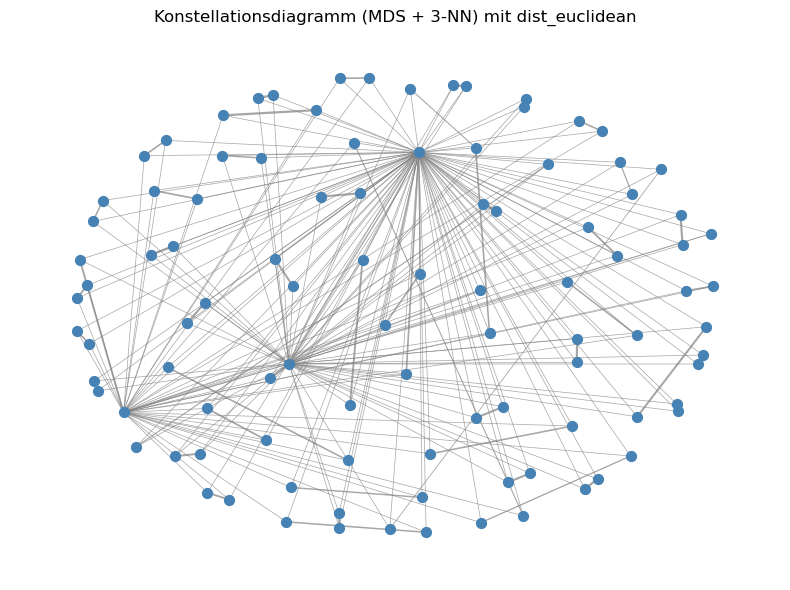

In [22]:
# %% Konstellationsdiagramm per MDS + kNN-Netzwerk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.manifold import MDS
from sklearn.neighbors import NearestNeighbors

# 1) CSV mit Distanzen laden
df = pd.read_csv(
    r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\cluster_csv.csv",
    decimal=","
)

measure = "dist_euclidean"
# Sammle alle Trail-IDs
trails = sorted(set(df["trail_a_id"]) | set(df["trail_b_id"]))
n = len(trails)

# 2) Distanzmatrix aufbauen und fehlende mit max füllen
D = pd.DataFrame(np.nan, index=trails, columns=trails)
for a, b, val in zip(df["trail_a_id"], df["trail_b_id"], df[measure]):
    D.at[a, b] = D.at[b, a] = float(val)
np.fill_diagonal(D.values, 0.0)
maxd = np.nanmax(D.values)
D = D.fillna(maxd)

# 3) MDS-Projektion in 2D
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(D.values)

# 4) k-Nearest-Neighbor‐Graph (z.B. k=3)
k = 3
nn = NearestNeighbors(n_neighbors=k+1, metric="precomputed")
nn.fit(D.values)
# Für jeden Punkt die Indizes der nächsten Nachbarn (inkl. sich selbst an Stelle 0)
distances, indices = nn.kneighbors(D.values)

G = nx.Graph()
# Knoten mit Position
for i, label in enumerate(trails):
    G.add_node(label, pos=(coords[i,0], coords[i,1]))

# Kanten zu den k nächsten Nachbarn
for i, nbrs in enumerate(indices):
    src = trails[i]
    for j in nbrs[1:]:  # skip den ersten Eintrag (sich selbst)
        tgt = trails[j]
        G.add_edge(src, tgt, weight=D.at[src, tgt])

# 5) Plot
pos = nx.get_node_attributes(G, 'pos')
plt.figure(figsize=(8,6))
# Kanten nach Gewicht einfärben / dick zeichnen
weights = [G[u][v]['weight'] for u,v in G.edges()]
# normalisieren für Breite
maxw = max(weights)
widths = [2*(1 - w/maxw) + 0.5 for w in weights]

nx.draw_networkx_nodes(G, pos, node_size=50, node_color='steelblue')
nx.draw_networkx_edges(G, pos, width=widths, edge_color='gray', alpha=0.7)
# optional Labels
# nx.draw_networkx_labels(G, pos, font_size=6)

plt.title(f"Konstellationsdiagramm (MDS + {k}-NN) mit {measure}")
plt.axis('off')
plt.tight_layout()
plt.savefig(output_dir / f"{measure}_konstellation.png", dpi=150)

plt.show()


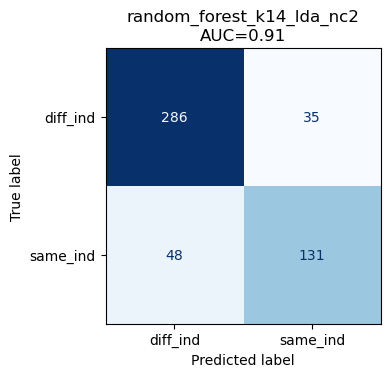

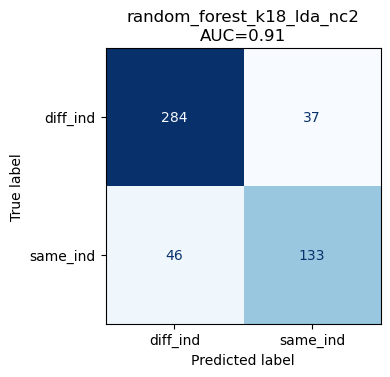

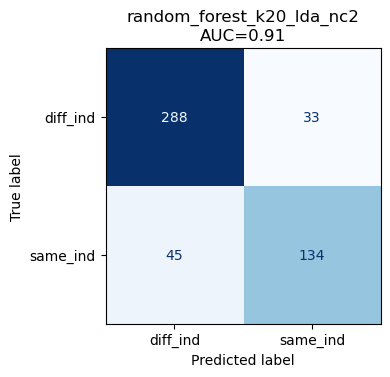

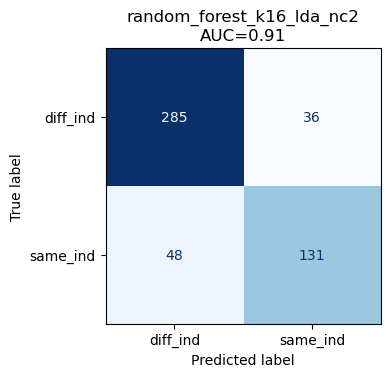

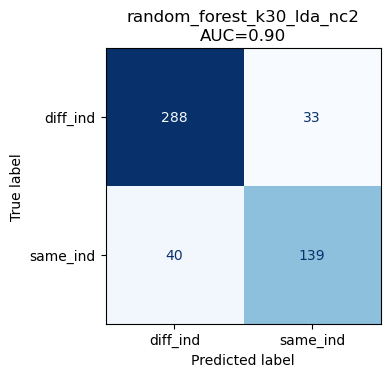

In [9]:
# Cell 4: Confusion matrices for top-5 pipelines
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# pick top 5 by AUC
top5 = res_df.nlargest(5, "auc_mean")["pipeline"].tolist()

gkf = GroupKFold(n_splits=5)

for pipe in top5:
    sub = df[df["pipeline"] == pipe]
    X = sub[features].values
    y = sub["same_individual"].astype(int).values
    groups = sub["comparison_id"].values

    clf = RandomForestClassifier(n_estimators=100, random_state=0)
    # get cross‐val predictions, grouping by comparison_id
    y_pred = cross_val_predict(
        clf, X, y,
        cv=gkf.split(X, y, groups),
        n_jobs=-1
    )

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["diff_ind","same_ind"])
    
    fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{pipe}\nAUC={res_df.set_index('pipeline').loc[pipe,'auc_mean']:.2f}")
    plt.tight_layout()
    plt.show()


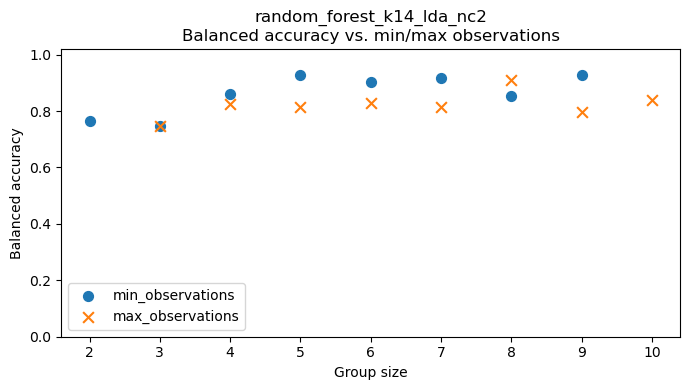

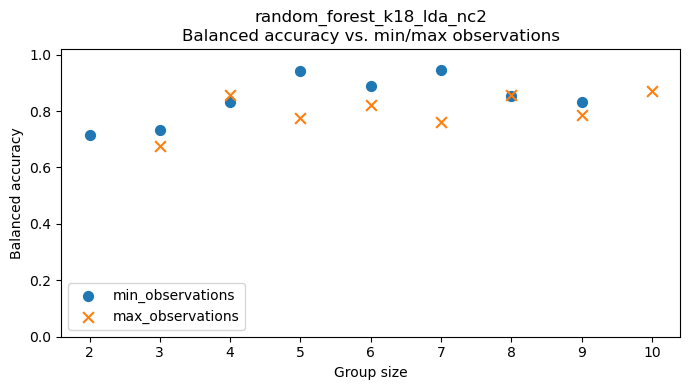

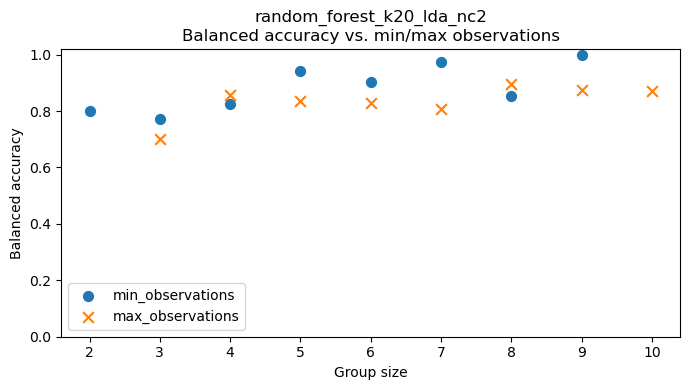

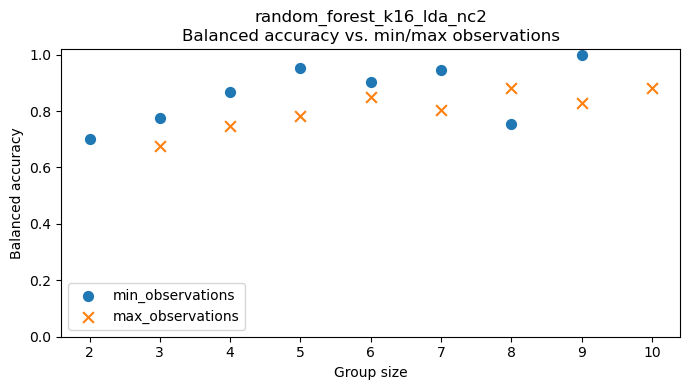

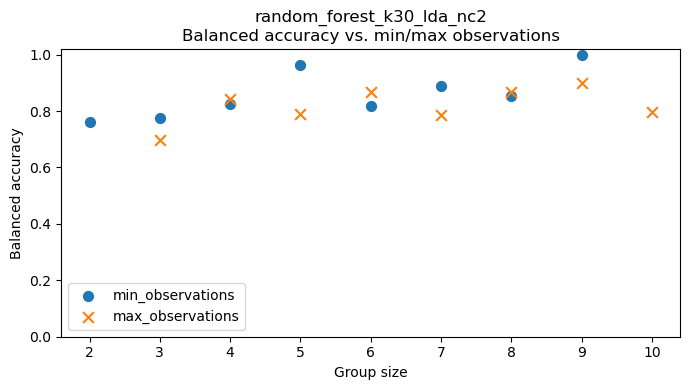

In [10]:
# Cell X: Balanced accuracy vs. min/max observations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score

# assume df_full (the full results DataFrame) and res_df (the grid‐search summary) are in memory,
# and that df_full has columns: 
#   ['pipeline','comparison_id','same_individual','min_observations','max_observations','dist_braycurtis','dist_cosine',...]
# and that you have already identified your top-5 pipelines:
top5 = res_df.nlargest(5, "auc_mean")["pipeline"].tolist()

for pipe in top5:
    sub = df[df["pipeline"] == pipe].copy()
    # build the feature matrix for the classifier
    X = sub[["dist_braycurtis","dist_cosine"]].values
    y = sub["same_individual"].astype(int).values
    groups = sub["comparison_id"].values

    # out-of-fold predictions
    gkf = GroupKFold(n_splits=5)
    clf = RandomForestClassifier(n_estimators=100, random_state=0)
    y_pred = cross_val_predict(clf, X, y,
                               cv=gkf.split(X, y, groups),
                               n_jobs=-1)

    sub["y_pred"] = y_pred

    # compute balanced accuracy per min_observations and max_observations
    ba_min = []
    for m in sorted(sub["min_observations"].unique()):
        grp = sub[sub["min_observations"] == m]
        if len(grp) < 10: 
            continue
        ba_min.append((m,
                       balanced_accuracy_score(grp["same_individual"], grp["y_pred"])))
    ba_min = pd.DataFrame(ba_min, columns=["group_size","balanced_accuracy"])

    ba_max = []
    for M in sorted(sub["max_observations"].unique()):
        grp = sub[sub["max_observations"] == M]
        if len(grp) < 10:
            continue
        ba_max.append((M,
                       balanced_accuracy_score(grp["same_individual"], grp["y_pred"])))
    ba_max = pd.DataFrame(ba_max, columns=["group_size","balanced_accuracy"])

    # plot
    fig, ax = plt.subplots(figsize=(7,4))
    ax.scatter(ba_min["group_size"], ba_min["balanced_accuracy"],
               label="min_observations", s=50)
    ax.scatter(ba_max["group_size"], ba_max["balanced_accuracy"],
               marker="x", label="max_observations", s=60)
    ax.set_xlabel("Group size")
    ax.set_ylabel("Balanced accuracy")
    ax.set_title(f"{pipe}\nBalanced accuracy vs. min/max observations")
    ax.set_ylim(0.0,1.02)
    ax.legend()
    plt.tight_layout()
    plt.show()



NameError: name 'methods' is not defined